## Exercise 01 : Line chart with styles

In [7]:
import pandas as pd
import sqlite3

### Make a connection to the database

In [8]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

### Run query

In [9]:
query = """
SELECT
    pageviews.date,
    pageviews.views,
    checker.commits
FROM (
    SELECT
        DATE(datetime) AS date,
        COUNT(*) AS views
    FROM
        pageviews
    WHERE
        uid LIKE 'user_%'
    GROUP BY
        date
) AS pageviews
INNER JOIN (
    SELECT
        DATE(timestamp) as date,
        COUNT(*) AS commits
    FROM
        checker
    WHERE
        uid LIKE 'user_%'
    GROUP BY
        date
) AS checker
ON checker.date = pageviews.date
"""
df = pd.read_sql(sql=query, con=conn, parse_dates='date')

In [10]:
len(df)

32

### Create a graph

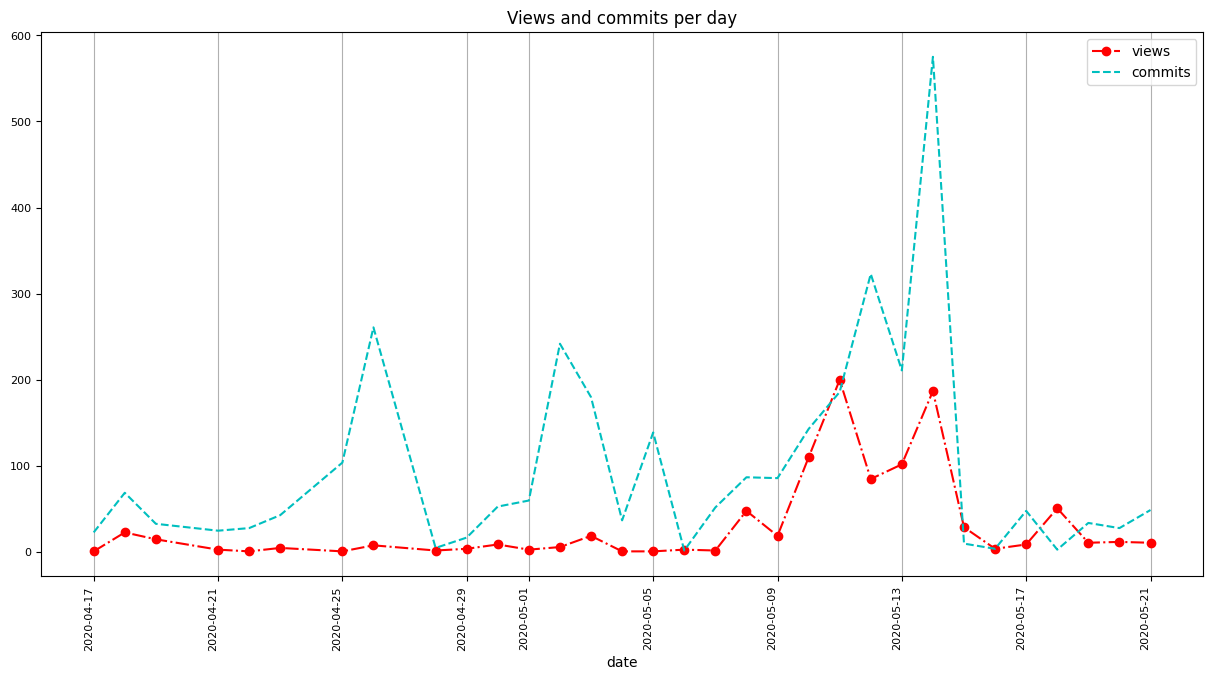

In [14]:
line_chart = df.plot(
    x='date',
    y=['views', 'commits'],
    kind='line',
    figsize=(15, 8),
    title='Views and commits per day',
    rot=90,
    fontsize=8,
    style=['r-.o', 'c--'],
    grid=True,
    legend=True,
    label=['views', 'commits']
)
line_chart.grid(axis='y')

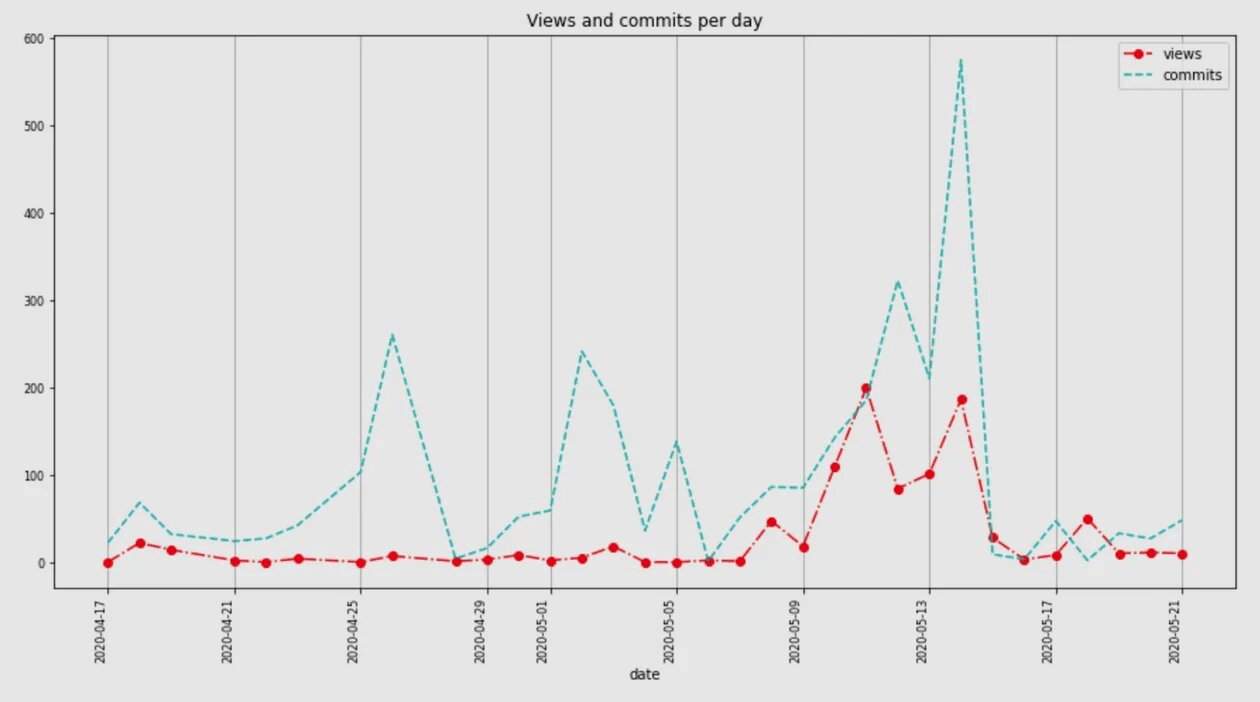

In [12]:
conn.close()

### “How many times was the number of views larger than 150?”

### “The answer is **2**”